In [1]:
!pip install nelson-siegel-svensson
# ============================================================
# PART 1 — 데이터 수집 · 전처리 · 모델 학습
# (v4 + Continual Learning + 32차원 + Vol-Managed + 15Y Rolling)
#
# 유지/변경 내역:
#   - EP, SVAR 매크로 변수 포함 유지 (MACRO_DIM = 11)
#   - 트랜스포머/어텐션 차원: embed_dim = 32 / MLP = 16 유지
#   - 고정 롤링 윈도우: Train 데이터를 15년(180개월)으로 고정, 앞부분도 1년씩 이동
#   - [수정 완료] Excess Sharpe Ratio 적용 (Total Sharpe -> Excess Sharpe 최적화)
#   - [수정 완료] Test Set Data Leakage 방지 (미래 데이터 참조 원천 차단)
#   - [추가 수정] 방어적 Vol-Managed 로직: 변동성이 타겟(10%)보다 클 때만 줄이고, 작아도 늘리진 않음 (max=1.0)
#   - [자산 추가] 기존 6자산(하이일드 포함) + 단기 회사채(VFSTX) 추가 -> 총 7자산
# ============================================================

import pandas as pd
import pandas_datareader.data as web
import yfinance as yf
import numpy as np
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"기기: {device} | 7자산 롱숏 모델 (32d + Defensive Vol-Managed + Rolling) 시작...\n")

# ----------------------------------------------------------
# 전역 상수
# ----------------------------------------------------------
NUM_ASSETS    = 7
MACRO_DIM     = 11
BASE_LR       = 1e-5
WARMUP_EPOCHS = 30
MAX_EPOCHS    = 100
PATIENCE      = 10
WINDOW_SIZE   = 240   # Train 학습 기간 고정: 15년 (180개월)
TARGET_VOL    = 0.10  # Volatility Managed 타겟 연 변동성 (10%)

ASSET_COLS = ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L',
              'TR_CORP_M',  'TR_CORP_L',  'TR_HY', 'TR_CORP_S']

MACRO_COLS = ['TBILL_RATE', 'SPREAD_10Y_3M', 'DFY', 'EP', 'SVAR',
              'SP500_RET', 'INFLATION_YoY', 'UNRATE',
              'Beta1', 'Beta2', 'Beta3']

REW_COLS   = ['REWARD_TREAS_S', 'REWARD_TREAS_M', 'REWARD_TREAS_L',
              'REWARD_CORP_M',  'REWARD_CORP_L',  'REWARD_HY', 'REWARD_CORP_S']

NORM_COLS  = ASSET_COLS + MACRO_COLS

# ==========================================
# 1. 뱅가드 펀드 7종 수익률 (Yahoo Finance)
# ==========================================
etf_tickers  = ['VFISX', 'VFITX', 'VUSTX', 'VFICX', 'VWESX', 'VWEHX', 'VFSTX']
asset_names7 = ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L',
                'TR_CORP_M',  'TR_CORP_L',  'TR_HY', 'TR_CORP_S']

print("1. Yahoo Finance 데이터 다운로드 중...")
df_raw = yf.download(etf_tickers, start='1990-01-01', end='2025-12-31', progress=False)

try:
    df_etf = df_raw['Adj Close'].resample('ME').last()
except KeyError:
    df_etf = df_raw['Close'].resample('ME').last()

if df_etf.index.tz is not None:
    df_etf.index = df_etf.index.tz_localize(None)
df_etf.index = df_etf.index.to_period('M')

df_portfolio = pd.DataFrame(index=df_etf.index)
for col, ticker in zip(asset_names7, etf_tickers):
    # 수익률을 bps 단위로 변환 (* 10000)
    df_portfolio[col] = df_etf[ticker].pct_change() * 10000

df_portfolio = df_portfolio.dropna()

for col in asset_names7:
    df_portfolio[col.replace('TR_', 'REWARD_')] = df_portfolio[col].shift(-1)

print(f" -> 7개 ETF 로드 완료 (길이: {len(df_portfolio)}개월)")

# ==========================================
# 2. FRED: CPI · UNRATE
# ==========================================
print("2. FRED 실물지표 로드 중...")
df_fred_raw = web.DataReader(
    ['CPIAUCSL', 'UNRATE'], 'fred', '1990-01-01', '2025-12-31'
).resample('ME').last()
df_fred_raw.index = df_fred_raw.index.to_period('M')

df_fred = pd.DataFrame(index=df_fred_raw.index)

df_fred['INFLATION_YoY'] = df_fred_raw['CPIAUCSL'].pct_change(12) * 100
df_fred['INFLATION_YoY'] = df_fred['INFLATION_YoY'].shift(1)

df_fred['UNRATE'] = df_fred_raw['UNRATE'].shift(1)

print(f" -> FRED 로드 완료 (길이: {len(df_fred)}개월)")

# ==========================================
# 3. Goyal-Welch CSV
# ==========================================
print("3. Goyal-Welch CSV 로드 중...")
try:
    file_path = 'PredictorData2024.xlsx - Monthly (1).csv'
    gw_df = pd.read_csv(file_path)
    gw_df['date'] = (pd.to_datetime(gw_df['yyyymm'].astype(str), format='%Y%m')
                     + pd.offsets.MonthEnd(0))

    if gw_df['Index'].dtype == 'O':
        gw_df['Index'] = gw_df['Index'].astype(str).str.replace(',', '').astype(float)

    gw_df['EP']            = np.log(gw_df['E12'] / gw_df['Index'])
    gw_df['SPREAD_10Y_3M'] = gw_df['lty'] - gw_df['tbl']
    gw_df['DFY']           = gw_df['BAA'] - gw_df['AAA']
    gw_df['SP500_RET']     = gw_df['Index'].pct_change()

    gw_macro = gw_df[['date', 'tbl', 'SPREAD_10Y_3M', 'DFY', 'EP', 'svar', 'SP500_RET']].copy()
    gw_macro.rename(columns={'tbl': 'TBILL_RATE', 'svar': 'SVAR'}, inplace=True)
    gw_macro.set_index('date', inplace=True)
    gw_macro.index = gw_macro.index.to_period('M')
    print(f" -> CSV 로드 완료 (길이: {len(gw_macro)}개월)")
except Exception as e:
    print(f" CSV 로드 에러: {e}")
    gw_macro = pd.DataFrame()

# ==========================================
# 4. FRED 국채 금리 → Nelson-Siegel Betas
# ==========================================
print("4. 국채 금리 및 Nelson-Siegel 베타 산출 중...")
yield_tickers = ['GS3M','GS6M','GS1','GS2','GS3','GS5','GS7','GS10','GS30']
df_yield = (web.DataReader(yield_tickers, 'fred', '1990-01-01', '2025-12-31')
            .resample('ME').last().ffill())
df_yield.index = df_yield.index.to_period('M')

maturities = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 30.0])

def get_betas(row):
    if row.isna().any():
        row = row.interpolate().bfill().ffill()
    try:
        curve, _ = calibrate_ns_ols(maturities, row.values, tau0=1.0)
        return pd.Series([curve.beta0, curve.beta1, curve.beta2],
                         index=['Beta1', 'Beta2', 'Beta3'])
    except:
        return pd.Series([np.nan, np.nan, np.nan],
                         index=['Beta1', 'Beta2', 'Beta3'])

df_yield_features = df_yield.apply(get_betas, axis=1)
print(f" -> NS 베타 산출 완료 (길이: {len(df_yield_features)}개월)")

# ==========================================
# 5. 전체 데이터 병합
# ==========================================
df_all_period = pd.concat([df_portfolio, gw_macro, df_fred, df_yield_features], axis=1)
df_all_period.index = df_all_period.index.to_timestamp(how='end')
df_all_raw = df_all_period.sort_index()

df_all = df_all_raw.loc['1993-11-01':'2024-12-31']
df_all = df_all.ffill().dropna()

print("=" * 55)
if len(df_all) == 0:
    print("[에러] 병합 후 데이터 0개.")
    raise ValueError("데이터 병합 실패")

df_all['YEAR'] = df_all.index.year
print(f"병합 성공 | 총 {len(df_all)}개월 | "
      f"{df_all.index[0].strftime('%Y-%m')} ~ {df_all.index[-1].strftime('%Y-%m')}")
print(f"자산 {NUM_ASSETS}개 : {ASSET_COLS}")
print(f"매크로 {MACRO_DIM}개: {MACRO_COLS}")
print("=" * 55)

# ==========================================
# 6. 모델 아키텍처 (embed_dim = 32)
# ==========================================
class PortfolioActor(nn.Module):
    def __init__(self, num_assets=NUM_ASSETS, asset_dim=1,
                 macro_dim=MACRO_DIM, embed_dim=32):
        super().__init__()

        self.a_proj = nn.Linear(asset_dim, embed_dim)
        self.a_tf   = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                embed_dim, nhead=2, batch_first=True, dropout=0.1),
            num_layers=1)

        self.m_proj = nn.Linear(macro_dim, embed_dim)
        self.m_tf   = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                embed_dim, nhead=2, batch_first=True, dropout=0.1),
            num_layers=1)

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads=2, batch_first=True)
        self.norm       = nn.LayerNorm(embed_dim)

        self.mlp_weight = nn.Sequential(
            nn.Linear(embed_dim + 1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, a_seq, m_seq, w_prev):
        B, L, N, D_a = a_seq.shape

        a_enc = self.a_tf(
            self.a_proj(a_seq.transpose(1, 2).reshape(B * N, L, D_a))
        )[:, -1, :].view(B, N, -1)

        m_enc = self.m_tf(self.m_proj(m_seq))

        m_query  = m_enc[:, -1:, :]
        attn_out, _ = self.cross_attn(query=m_query,
                                      key=a_enc, value=a_enc)
        attn_out = attn_out.expand(-1, N, -1)
        ctx      = self.norm(a_enc + attn_out)

        combined = torch.cat([ctx, w_prev.unsqueeze(-1)], dim=-1)
        w_raw    = 2.0 * torch.tanh(self.mlp_weight(combined).squeeze(-1))

        # 기본 포트폴리오 가중치 제약 (레버리지 기초 캡)
        gross = w_raw.abs().sum(dim=-1, keepdim=True).clamp(min=1e-6)
        w     = torch.where(gross > 2.0, w_raw * (2.0 / gross), w_raw)
        return w


# ==========================================
# 7. 데이터셋 준비 (과거 12개월 수익률 추가 반환)
# ==========================================
def get_dataset_tensors(df, lookback=12):
    a_data = np.stack([df[[c]].values for c in ASSET_COLS], axis=1)
    # 정규화 전의 원본 데이터(RAW)를 활용해 정확한 Volatility 계산용 시퀀스 준비
    raw_a_data = np.stack([df[[c+'_RAW']].values for c in ASSET_COLS], axis=1)

    m_data = df[MACRO_COLS].values
    r_data = df[REW_COLS].values

    a_seq, m_seq, rew, past_r = [], [], [], []
    for i in range(len(df) - lookback):
        a_seq.append(a_data[i:i+lookback])
        m_seq.append(m_data[i:i+lookback])
        rew.append(r_data[i+lookback-1])
        # 직전 12개월의 원본 수익률 (Shape: 12 x 7)
        past_r.append(raw_a_data[i:i+lookback, :, 0])

    return (torch.tensor(np.array(a_seq),  dtype=torch.float32),
            torch.tensor(np.array(m_seq),  dtype=torch.float32),
            torch.tensor(np.array(past_r), dtype=torch.float32),
            torch.tensor(np.array(rew),    dtype=torch.float32))


# ==========================================
# 8. 학습 루프 (Rolling 15년 고정 + Vol-Managed)
# ==========================================
test_years         = range(2016, 2025)
rl_weights_history = []
test_dates_history = []
all_dates          = df_all.index

set_seed(42)
model = PortfolioActor(embed_dim=32).to(device)

for i, target_year in enumerate(test_years):
    mask = (all_dates.year == target_year)
    if not mask.any():
        continue

    test_start = np.where(mask)[0][0]
    val_start  = test_start - 24
    train_end  = val_start

    # [유지] 고정 롤링 윈도우: 15년(180개월) 단위로 꼬리 부분 자르기
    train_start = max(0, train_end - WINDOW_SIZE)

    train_df = df_all.iloc[train_start:train_end].copy()
    val_df   = df_all.iloc[val_start - 12 : val_start + 24].copy()

    # =======================================================
    # [수정 #2] Test Set Data Leakage 방지
    # =======================================================
    target_year_df = df_all[df_all.index.year == target_year]
    lookback_df    = df_all.iloc[test_start - 12 : test_start]
    test_df        = pd.concat([lookback_df, target_year_df]).copy()
    # =======================================================

    # =======================================================
    # [수정 #1] Excess Sharpe 산출을 위한 무위험수익률(bps) 추출
    # =======================================================
    rf_monthly_bps = (train_df['TBILL_RATE'].mean() / 12.0) * 100.0
    # =======================================================

    # 정규화 전 원본 자산 수익률 보존 (Volatility 계산에 필수)
    for df_ in [train_df, val_df, test_df]:
        for c in ASSET_COLS:
            df_[c+'_RAW'] = df_[c]

    # [중요] 롤링될 때마다 매번 새로운 Train 셋으로 정규화
    t_mean = train_df[NORM_COLS].mean()
    t_std  = train_df[NORM_COLS].std().replace(0, 1e-8)
    for df_ in [train_df, val_df, test_df]:
        df_[NORM_COLS] = (df_[NORM_COLS] - t_mean) / t_std

    tr_a, tr_m, tr_past_r, tr_r = get_dataset_tensors(train_df)
    va_a, va_m, va_past_r, va_r = get_dataset_tensors(val_df)
    te_a, te_m, te_past_r, te_r = get_dataset_tensors(test_df)

    current_base_lr = BASE_LR
    optimizer  = torch.optim.Adam(model.parameters(),
                                   lr=current_base_lr,
                                   weight_decay=1e-4)
    best_val   = float('inf')
    no_improve = 0

    print(f"\n[{target_year}] Rolling (20Y) + Continual Learning "
          f"Train: {train_df.index[12].strftime('%Y-%m')}~{train_df.index[-1].strftime('%Y-%m')} | "
          f"Val: {val_df.index[12].strftime('%Y-%m')}~{val_df.index[-1].strftime('%Y-%m')}")

    for epoch in range(MAX_EPOCHS):
        if epoch < WARMUP_EPOCHS:
            current_lr = current_base_lr * (epoch + 1) / WARMUP_EPOCHS
        else:
            progress   = (epoch - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1)
            current_lr = current_base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

        # ── Train ──────────────────────────────────────────
        model.train()
        optimizer.zero_grad()

        w_prev       = torch.ones(tr_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
        returns_list = []

        for t in range(tr_a.size(0)):
            w_raw = model(tr_a[t:t+1].to(device),
                          tr_m[t:t+1].to(device),
                          w_prev[t:t+1])

            # Volatility-Managed Logic
            past_returns = tr_past_r[t:t+1].to(device)
            past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)

            realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

            # [핵심 수정]: max=1.0으로 설정하여 변동성이 작을 때 레버리지를 일으켜 늘리지 않음
            scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
            w_managed    = w_raw * scale_factor

            R_t = torch.sum(w_managed * tr_r[t:t+1].to(device))
            returns_list.append(R_t)

            if t < tr_a.size(0) - 1:
                w_prev[t+1:t+2] = w_managed.detach()

        returns_t = torch.stack(returns_list)

        # =======================================================
        # [수정 #1] Excess Sharpe Ratio (초과 수익률 기준 적용)
        # =======================================================
        excess_returns_t = returns_t - rf_monthly_bps
        mean_r    = excess_returns_t.mean()
        std_r     = excess_returns_t.std() + 1e-6
        loss      = -(mean_r * math.sqrt(12)) / std_r
        # =======================================================

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # ── Validation ─────────────────────────────────────
        model.eval()
        with torch.no_grad():
            vw = torch.ones(va_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
            vr = []
            for t in range(va_a.size(0)):
                w_raw = model(va_a[t:t+1].to(device),
                              va_m[t:t+1].to(device),
                              vw[t:t+1])

                # Validation Vol-Managed Logic
                past_returns = va_past_r[t:t+1].to(device)
                past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)
                realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

                # [핵심 수정]: max=1.0
                scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
                w_managed    = w_raw * scale_factor

                vr.append(torch.sum(w_managed * va_r[t:t+1].to(device)))
                if t < va_a.size(0) - 1:
                    vw[t+1:t+2] = w_managed

            vr_t  = torch.stack(vr)

            # =======================================================
            # [수정 #1] Validation에도 Excess Sharpe 반영
            # =======================================================
            excess_vr_t = vr_t - rf_monthly_bps
            vloss = -((excess_vr_t.mean() * math.sqrt(12)) / (excess_vr_t.std() + 1e-6)).item()
            # =======================================================

        improved = (vloss < best_val)
        if improved:
            best_val   = vloss
            no_improve = 0
            torch.save(model.state_dict(), f"best_{target_year}.pth")
        else:
            no_improve += 1

        tag = " ← best" if improved else f" (patience {no_improve}/{PATIENCE})"
        print(f"  ep {epoch+1:3d} | val_sharpe={-vloss:6.4f} | lr={current_lr:.2e}{tag}")

        if no_improve >= PATIENCE:
            print(f"  → Early stop @ epoch {epoch+1}")
            break

    # ── Test ───────────────────────────────────────────────
    model.load_state_dict(torch.load(f"best_{target_year}.pth", map_location=device))
    model.eval()

    with torch.no_grad():
        tw = torch.ones(te_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
        for t in range(te_a.size(0)):
            w_raw = model(te_a[t:t+1].to(device),
                          te_m[t:t+1].to(device),
                          tw[t:t+1])

            # Test Vol-Managed Logic
            past_returns = te_past_r[t:t+1].to(device)
            past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)
            realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

            # [핵심 수정]: max=1.0
            scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
            w_managed    = w_raw * scale_factor

            # 실제 투자되는 스케일링된 가중치를 보존
            rl_weights_history.append(w_managed.cpu().numpy()[0])
            if t < te_a.size(0) - 1:
                tw[t+1:t+2] = w_managed

    # 정확히 타겟 연도의 Date만 append 되도록 반영 (lookback 길이인 12번째 이후)
    test_dates_history.append(test_df.index[12:])

print("\n[7자산 RL 헤지펀드 v4] 백테스트 완료")
print("  └  Rolling Window | Defensive Vol-Managed (방어적 비중 축소만) | Excess Sharpe 최적화 적용 완료")

기기: cuda | 7자산 롱숏 모델 (32d + Defensive Vol-Managed + Rolling) 시작...

1. Yahoo Finance 데이터 다운로드 중...
 -> 7개 ETF 로드 완료 (길이: 386개월)
2. FRED 실물지표 로드 중...
 -> FRED 로드 완료 (길이: 432개월)
3. Goyal-Welch CSV 로드 중...
 -> CSV 로드 완료 (길이: 1848개월)
4. 국채 금리 및 Nelson-Siegel 베타 산출 중...
 -> NS 베타 산출 완료 (길이: 432개월)
병합 성공 | 총 374개월 | 1993-11 ~ 2024-12
자산 7개 : ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L', 'TR_CORP_M', 'TR_CORP_L', 'TR_HY', 'TR_CORP_S']
매크로 11개: ['TBILL_RATE', 'SPREAD_10Y_3M', 'DFY', 'EP', 'SVAR', 'SP500_RET', 'INFLATION_YoY', 'UNRATE', 'Beta1', 'Beta2', 'Beta3']

[2016] Rolling (20Y) + Continual Learning Train: 1995-01~2013-12 | Val: 2014-01~2015-12
  ep   1 | val_sharpe=1.0446 | lr=3.33e-07 ← best
  ep   2 | val_sharpe=1.0447 | lr=6.67e-07 ← best
  ep   3 | val_sharpe=1.0447 | lr=1.00e-06 ← best
  ep   4 | val_sharpe=1.0448 | lr=1.33e-06 ← best
  ep   5 | val_sharpe=1.0450 | lr=1.67e-06 ← best
  ep   6 | val_sharpe=1.0452 | lr=2.00e-06 ← best
  ep   7 | val_sharpe=1.0453 | lr=2.33e-06 ← best
  e

Basic MVO 벤치마크 계산 중 (7자산 롱숏 롤링)...

===== 성과 평가 (2016–2024) | 20Y Rolling · Vol-Managed 10% =====

[1. RL Agent (20Y Rolling · Vol-Managed 10% · 32d)]
  누적 수익률 :    48.52%  | 연평균 수익 :    4.73%
  변동성(Std) :     8.13%  | 연 분산     : 0.006602
  샤프 지수   :   0.5799   | 최대 낙폭   :  -19.38%

[2. Basic MVO (Long-Short 2x)]
  누적 수익률 :     7.93%  | 연평균 수익 :    0.91%
  변동성(Std) :     3.39%  | 연 분산     : 0.001147
  샤프 지수   :   0.2619   | 최대 낙폭   :  -15.45%



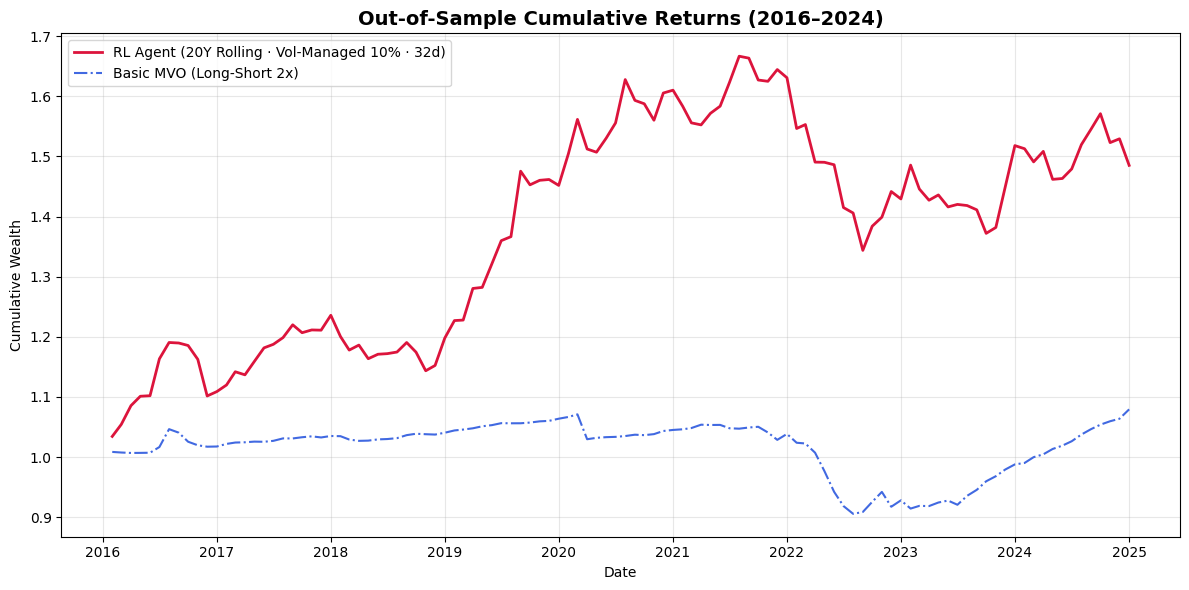

In [2]:
# ============================================================
# PART 2 — 성과 평가 · 벤치마크 비교 · 시각화 (v4 수정판 반영)
#
# ※ Part 1(15Y Rolling + Vol-Managed + 32차원)에서 넘어온 변수:
#    rl_weights_history, test_dates_history,
#    df_all, ASSET_COLS, NUM_ASSETS (=7)
# ============================================================

import scipy.optimize as sco
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import random
import math

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ── Part 1에서 넘어온 변수 ───────────────────────────────────
# final_rl_w에는 타겟 변동성(10%)에 맞춰 스케일링된 가중치가 들어있습니다.
final_rl_w  = np.array(rl_weights_history)
final_dates = pd.DatetimeIndex(np.concatenate(test_dates_history))

# [자산 추가]: 기존 6개 + CORP_S (IG Short) 추가 -> 총 7개
asset_labels = [
    'TREAS_S (Short)',   'TREAS_M (Mid)',    'TREAS_L (Long)',
    'CORP_M (IG Mid)',   'CORP_L (IG Long)', 'HY (High Yield)', 'CORP_S (IG Short)'
]
num_assets = NUM_ASSETS  # 7

# ==========================================
# 1. 실제 수익률 복원 및 무위험 수익률(RF) 추출
# ==========================================
raw_returns      = df_all[ASSET_COLS] / 10000.0
test_raw_returns = raw_returns.loc[final_dates].values
# Vol-Managed 가중치와 실제 자산 수익률을 내적하여 최종 포트폴리오 수익률 계산
rl_returns       = np.sum(final_rl_w * test_raw_returns, axis=1)

rf_series        = df_all['TBILL_RATE'] / 1200.0
rf_returns_test  = rf_series.loc[final_dates].values

# ==========================================
# 2. 기본 MVO 벤치마크 (7자산, 롱숏 2x 롤링, 표본 공분산 사용)
# ==========================================
print(f"Basic MVO 벤치마크 계산 중 ({num_assets}자산 롱숏 롤링)...")
mvo_weights_history = []

for date in final_dates:
    lookback_data = raw_returns.loc[:date].iloc[-13:-1].values
    lookback_rf   = rf_series.loc[:date].iloc[-13:-1].values

    # 단순 표본 공분산 (Sample Covariance) 사용
    cov_matrix = np.cov(lookback_data, rowvar=False)
    mean_ret   = lookback_data.mean(axis=0)
    rf_mean    = lookback_rf.mean()

    def negative_sharpe(w):
        p_ret      = np.sum(mean_ret * w)
        excess_ret = p_ret - rf_mean
        p_vol      = np.sqrt(w @ cov_matrix @ w)
        return -excess_ret / (p_vol + 1e-6)

    constraints = [
        {'type': 'eq',   'fun': lambda x: np.sum(x) - 1.0},
        {'type': 'ineq', 'fun': lambda x: 2.0 - np.sum(np.abs(x))},
    ]
    bounds     = tuple((-0.5, 1.5) for _ in range(num_assets))
    init_guess = [1.0 / num_assets] * num_assets

    result = sco.minimize(negative_sharpe, init_guess,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    mvo_weights_history.append(result.x)

final_mvo_w = np.array(mvo_weights_history)
mvo_returns = np.sum(final_mvo_w * test_raw_returns, axis=1)



# ==========================================
# 4. 성과 지표 산출 (칼마 지수 제외 버전)
# ==========================================
def calc_metrics(returns, rf_returns, name):
    cum_ret        = np.cumprod(1 + returns)
    total_return   = (cum_ret[-1] - 1) * 100
    ann_mean       = np.mean(returns) * 12 * 100
    ann_var        = np.var(returns)  * 12
    ann_std        = np.std(returns)  * np.sqrt(12) * 100
    excess_returns = returns - rf_returns
    sharpe         = (np.mean(excess_returns) * np.sqrt(12)) / (np.std(excess_returns) + 1e-6)
    mdd            = (cum_ret / np.maximum.accumulate(cum_ret) - 1).min() * 100

    print(f"[{name}]")
    print(f"  누적 수익률 : {total_return:8.2f}%  | 연평균 수익 : {ann_mean:7.2f}%")
    print(f"  변동성(Std) : {ann_std:8.2f}%  | 연 분산     : {ann_var:.6f}")
    print(f"  샤프 지수   : {sharpe:8.4f}   | 최대 낙폭   : {mdd:7.2f}%\n")
    return cum_ret

start_yr = final_dates[0].strftime('%Y')
end_yr   = final_dates[-1].strftime('%Y')

print(f"\n===== 성과 평가 ({start_yr}–{end_yr}) | 20Y Rolling · Vol-Managed 10% =====\n")
cum_rl  = calc_metrics(rl_returns,  rf_returns_test,
                       "1. RL Agent (20Y Rolling · Vol-Managed 10% · 32d)")
cum_mvo = calc_metrics(mvo_returns, rf_returns_test,
                       "2. Basic MVO (Long-Short 2x)")

# ==========================================
# 5. 시각화 (수정 완료)
# ==========================================
# 1행 1열의 단일 그래프 생성 (fig와 ax를 동시에 정의)
fig, ax = plt.subplots(figsize=(12, 6))

# 누적 수익률 그래프 그리기
ax.plot(final_dates, cum_rl,  lw=2,   color='crimson',
        label='RL Agent (20Y Rolling · Vol-Managed 10% · 32d)')
ax.plot(final_dates, cum_mvo, lw=1.5, color='royalblue', ls='-.',
        label='Basic MVO (Long-Short 2x)')

# 그래프 스타일 설정
ax.set_title(f'Out-of-Sample Cumulative Returns ({start_yr}–{end_yr})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Wealth')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#experiments


=== RL Agent 월별 자산 비중 및 롱/숏(Long/Short) 포지션 (7 Assets) ===
           TR_TREAS_S    TR_TREAS_M    TR_TREAS_L     TR_CORP_M     TR_CORP_L         TR_HY     TR_CORP_S
Date                                                                                                     
2016-01    21.88% (L)    29.08% (L)    37.63% (L)    27.23% (L)    29.51% (L)    23.92% (L)    21.49% (L)
2016-02    29.40% (L)    30.79% (L)    30.52% (L)    30.52% (L)    30.11% (L)    18.26% (L)    30.40% (L)
2016-03    23.21% (L)    32.00% (L)    29.98% (L)    31.80% (L)    30.59% (L)    29.29% (L)    23.13% (L)
2016-04    26.31% (L)    28.41% (L)    28.51% (L)    29.44% (L)    29.48% (L)    29.12% (L)    28.73% (L)
2016-05    18.47% (L)    25.05% (L)    25.95% (L)    34.06% (L)    32.50% (L)    30.91% (L)    33.07% (L)
2016-06    19.70% (L)    26.20% (L)    39.28% (L)    26.66% (L)    34.92% (L)    30.88% (L)    22.36% (L)
2016-07    27.34% (L)    28.97% (L)    29.25% (L)    29.09% (L)    29.57% (L)    27.73% (L) 

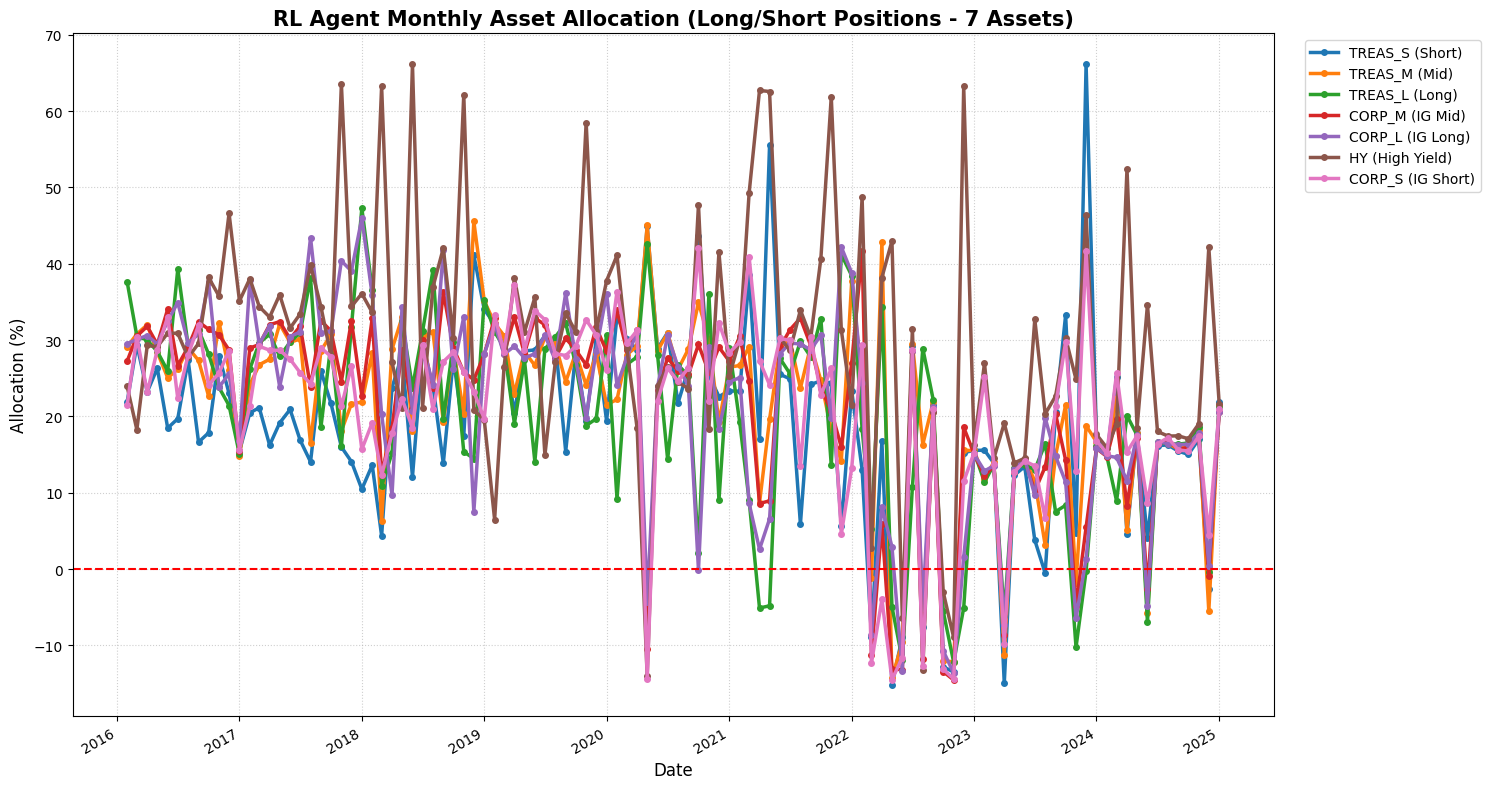

In [3]:
# ============================================================
# PART 3 — 월별 자산 비중 및 롱/숏 포지션 표 출력 및 저장
# (7자산 모델 반영: 기존 6개 + 단기 회사채 추가)
# ============================================================

# 1. RL 모델 가중치를 DataFrame으로 변환
df_weights = pd.DataFrame(final_rl_w, index=final_dates, columns=ASSET_COLS)

# 2. 비중(%) 계산 및 롱(L)/숏(S) 텍스트 포맷팅 함수 정의
def format_position(w):
    w_pct = w * 100
    # 0.01% 이상은 Long(L), -0.01% 이하는 Short(S), 그 외는 중립(-)으로 표기
    if w_pct > 0.01:
        return f"{w_pct:>7.2f}% (L)"
    elif w_pct < -0.01:
        return f"{w_pct:>7.2f}% (S)"
    else:
        return f"{w_pct:>7.2f}% (-)"

# 3. 데이터프레임 전체에 포맷팅 적용 (pandas 최신 버전 호환을 위해 apply-map 사용)
df_rl_formatted = df_weights.apply(lambda col: col.map(format_position))

# 4. 가독성을 위해 인덱스를 연-월(YYYY-MM)로 변경
df_rl_formatted.index = df_rl_formatted.index.strftime('%Y-%m')
df_rl_formatted.index.name = 'Date'

# 5. 콘솔에 표 출력
print("\n" + "="*95)
print("=== RL Agent 월별 자산 비중 및 롱/숏(Long/Short) 포지션 (7 Assets) ===")
print("="*95)
print(df_rl_formatted.to_string())


# ============================================================
# PART 4 — RL Agent 월별 포지션 시각화 (Line Chart)
# ============================================================

import matplotlib.pyplot as plt

def plot_positions_line(df_weights, asset_labels):
    # 비중을 퍼센트로 변환
    df_plot = df_weights * 100

    # 1. 시각화 영역 설정
    fig, ax = plt.subplots(figsize=(15, 8))

    # 2. Line Chart 그리기 (7개 자산을 loop 돌며 각각의 선으로 플롯)
    # 가독성을 위해 선 두께(lw)를 살리고, 데이터 포인트를 점(marker)으로 표시했습니다.
    for col, label in zip(df_plot.columns, asset_labels):
        ax.plot(df_plot.index, df_plot[col], label=label, linewidth=2.5, marker='o', markersize=4)

    # 3. 그래프 스타일링
    ax.axhline(0, color='red', lw=1.5, ls='--') #  0% 기준선 (롱/숏을 가르는 중요한 구분선)
    ax.set_title('RL Agent Monthly Asset Allocation (Long/Short Positions - 7 Assets)', fontsize=15, fontweight='bold')
    ax.set_ylabel('Allocation (%)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)

    # 범례 및 그리드 (선들이 겹치므로 격자를 조금 더 명확하게 설정)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    # X축 날짜 라벨이 겹치지 않도록 자동 회전 및 정렬
    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()

# 함수 실행 (변경된 선 그래프 함수 호출)
plot_positions_line(df_weights, asset_labels)

어텐션맵 분석 시작 (PART 2)

[2016] 어텐션 가중치 추출 중...
  attn_mean shape  : (2, 7)
  grad_mean shape  : (11,)
  헤드 평균 (7자산): [0.1943 0.1458 0.13   0.1264 0.1198 0.1321 0.1515]

[2017] 어텐션 가중치 추출 중...
  attn_mean shape  : (2, 7)
  grad_mean shape  : (11,)
  헤드 평균 (7자산): [0.211  0.1543 0.1317 0.1323 0.108  0.1029 0.1599]

[2018] 어텐션 가중치 추출 중...
  attn_mean shape  : (2, 7)
  grad_mean shape  : (11,)
  헤드 평균 (7자산): [0.1623 0.1365 0.1323 0.1426 0.1378 0.126  0.1625]

[2019] 어텐션 가중치 추출 중...
  attn_mean shape  : (2, 7)
  grad_mean shape  : (11,)
  헤드 평균 (7자산): [0.1563 0.1471 0.1531 0.1297 0.1293 0.1519 0.1326]

[2020] 어텐션 가중치 추출 중...
  attn_mean shape  : (2, 7)
  grad_mean shape  : (11,)
  헤드 평균 (7자산): [0.1396 0.1376 0.1463 0.134  0.1441 0.1589 0.1396]

[2021] 어텐션 가중치 추출 중...
  attn_mean shape  : (2, 7)
  grad_mean shape  : (11,)
  헤드 평균 (7자산): [0.1752 0.1471 0.1471 0.139  0.1356 0.1024 0.1535]

[2022] 어텐션 가중치 추출 중...
  attn_mean shape  : (2, 7)
  grad_mean shape  : (11,)
  헤드 평균 (7자산): [0.1523 0.1394 0

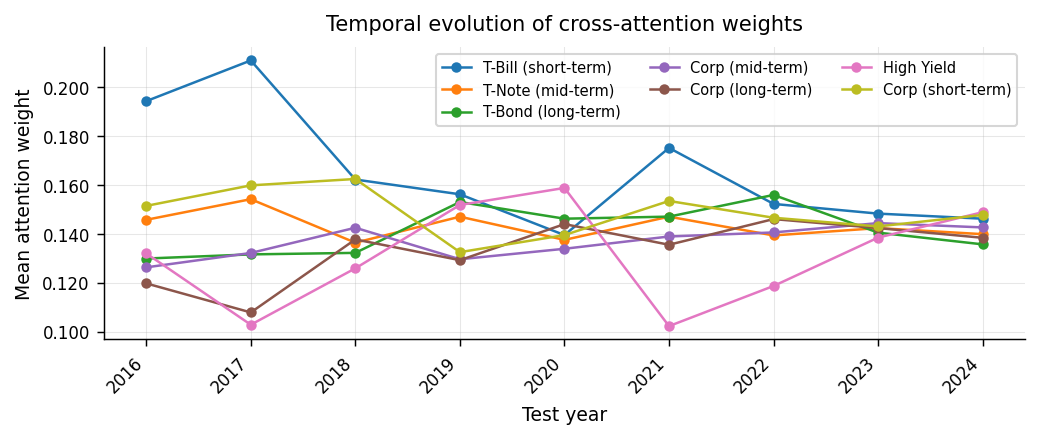

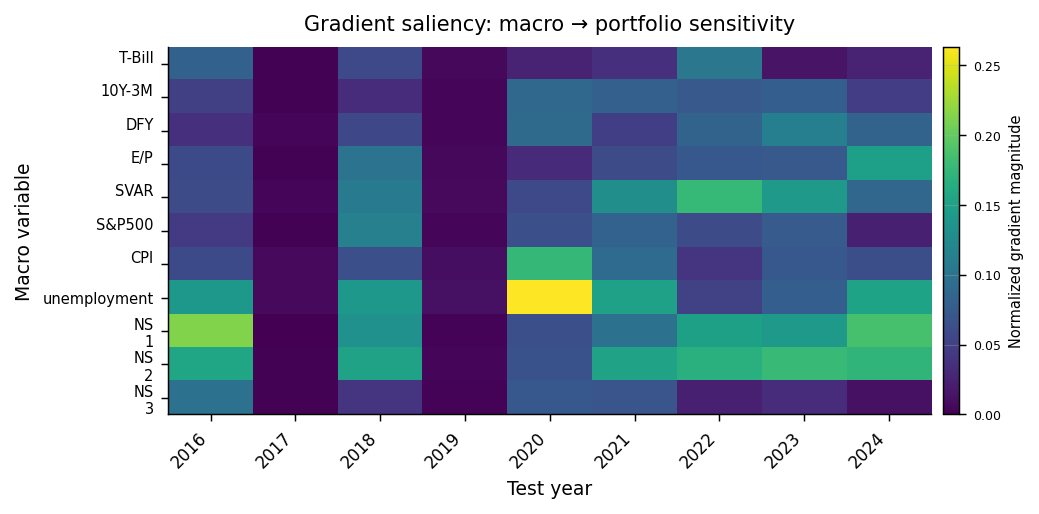

 fig2 시각화 출력 완료
 fig3 시각화 출력 완료

[수치 요약] 연도별 헤드-평균 어텐션 가중치
Year  |  T-Short |    T-Mid |   T-Long |   Corp-M |   Corp-L |       HY |   Corp-S
----------------------------------------------------------------------------------
2016  |   0.1943 |   0.1458 |   0.1300 |   0.1264 |   0.1198 |   0.1321 |   0.1515
2017  |   0.2110 |   0.1543 |   0.1317 |   0.1323 |   0.1080 |   0.1029 |   0.1599
2018  |   0.1623 |   0.1365 |   0.1323 |   0.1426 |   0.1378 |   0.1260 |   0.1625
2019  |   0.1563 |   0.1471 |   0.1531 |   0.1297 |   0.1293 |   0.1519 |   0.1326
2020  |   0.1396 |   0.1376 |   0.1463 |   0.1340 |   0.1441 |   0.1589 |   0.1396
2021  |   0.1752 |   0.1471 |   0.1471 |   0.1390 |   0.1356 |   0.1024 |   0.1535
2022  |   0.1523 |   0.1394 |   0.1560 |   0.1407 |   0.1461 |   0.1188 |   0.1467
2023  |   0.1484 |   0.1424 |   0.1406 |   0.1445 |   0.1425 |   0.1386 |   0.1431
2024  |   0.1463 |   0.1400 |   0.1358 |   0.1427 |   0.1385 |   0.1490 |   0.1478

[수치 요약] 연도별 Gradient Salien

In [4]:
# ============================================================
# PART 2 — 어텐션맵 추출
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import warnings
import math

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          9,
    'axes.titlesize':     10,
    'axes.labelsize':     9,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'legend.fontsize':    8,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linewidth':     0.5,
    'lines.linewidth':    1.2,
    'axes.linewidth':     0.7,
    'xtick.major.width':  0.7,
    'ytick.major.width':  0.7,
})

# 전역 상수 (PART 1에서 정의된 것과 일치해야 함)
# [수정] 자산 라벨 7개로 확장 (단기 회사채 추가)
ASSET_LABELS  = ['T-Bill\n(short-term)', 'T-Note\n(mid-term)', 'T-Bond\n(long-term)',
                 'Corp\n(mid-term)', 'Corp\n(long-term)', 'High\nYield', 'Corp\n(short-term)']
MACRO_LABELS  = ['T-Bill\n', '10Y-3M\n', 'DFY\n',
                 'E/P\n', 'SVAR\n',
                 'S&P500\n', 'CPI\n', 'unemployment',
                 'NS\n1', 'NS\n2', 'NS\n3']

CMAP_MAIN = 'RdYlBu_r'   # 학계 표준 발산형 colormap
CMAP_SEQ  = 'YlOrRd'     # 시계열용 순차형 colormap


# ============================================================
# 1. 어텐션 가중치 추출기 (Forward Hook)
# ============================================================
class AttentionExtractor:
    """
    PyTorch nn.MultiheadAttention에서 어텐션 가중치를 추출하는 Hook.

    사용법:
        extractor = AttentionExtractor(model.cross_attn)
        with extractor:
            output = model(...)
        weights = extractor.weights  # shape: (B, num_heads, Tq, Tk)
    """

    def __init__(self, attn_module: torch.nn.MultiheadAttention):
        self.module  = attn_module
        self.weights = None
        self._hook   = None

    def __enter__(self):
        # need_weights=True, average_attn_weights=False → 헤드별 분리 추출
        original_forward = self.module.forward

        def hooked_forward(query, key, value, **kwargs):
            kwargs['need_weights']           = True
            kwargs['average_attn_weights']   = False  # (B, H, Tq, Tk)
            out, attn_w = original_forward(query, key, value, **kwargs)
            self.weights = attn_w.detach().cpu()
            return out, attn_w

        self._patched = hooked_forward
        self.module.forward = hooked_forward
        return self

    def __exit__(self, *args):
        self.module.forward = self.module.__class__.forward.__get__(
            self.module, self.module.__class__)
        if self._hook is not None:
            self._hook.remove()


def extract_attention_for_period(
        model_: torch.nn.Module,
        df_period: pd.DataFrame,
        t_mean_: pd.Series,
        t_std_:  pd.Series,
        lookback: int = 12) -> dict:
    """
    特定 기간(df_period)에 대한 어텐션 가중치를 추출.

    Returns
    -------
    dict with keys:
        'raw_weights' : np.ndarray, shape (T, num_heads, 1, N_assets)
        'mean_weights': np.ndarray, shape (T, N_assets)  — 헤드 평균
        'dates'       : pd.DatetimeIndex
    """
    # 정규화 (Train 통계 기준)
    df_ = df_period.copy()
    for c in ASSET_COLS:
        df_[c + '_RAW'] = df_[c]
    df_[NORM_COLS] = (df_[NORM_COLS] - t_mean_) / t_std_

    a_data = np.stack([df_[[c]].values for c in ASSET_COLS], axis=1)
    m_data = df_[MACRO_COLS].values

    all_raw, all_mean, valid_dates = [], [], []
    extractor = AttentionExtractor(model_.cross_attn)

    model_.eval()
    with torch.no_grad():
        w_prev = torch.ones(1, NUM_ASSETS).to(device) / NUM_ASSETS

        for i in range(len(df_) - lookback):
            a_seq = torch.tensor(
                a_data[i:i+lookback][np.newaxis], dtype=torch.float32).to(device)
            m_seq = torch.tensor(
                m_data[i:i+lookback][np.newaxis], dtype=torch.float32).to(device)

            with extractor:
                _ = model_(a_seq, m_seq, w_prev)

            if extractor.weights is not None:
                # weights: (1, num_heads, 1, N_assets=7)
                w_np    = extractor.weights.numpy()          # (1, H, 1, 7)
                head_avg = w_np[0, :, 0, :].mean(axis=0)    # (7,)
                all_raw.append(w_np[0])                     # (H, 1, 7)
                all_mean.append(head_avg)
                valid_dates.append(df_.index[i + lookback - 1])

            w_prev = w_prev.detach()

    return {
        'raw_weights':  np.stack(all_raw,  axis=0),   # (T, H, 1, 7)
        'mean_weights': np.stack(all_mean, axis=0),   # (T, 7)
        'dates':        pd.DatetimeIndex(valid_dates),
    }


# ============================================================
# 2. 매크로-자산 간 크로스 어텐션 분석
#    (query=매크로 벡터 vs key=자산 인코딩)
# ============================================================
def extract_macro_asset_attention(
        model_: torch.nn.Module,
        df_period: pd.DataFrame,
        t_mean_: pd.Series,
        t_std_:  pd.Series,
        lookback: int = 12) -> dict:
    """
    매크로 × 자산 간 어텐션 행렬을 추출.

    cross_attn의 query는 macro hidden state (dim=embed_dim),
    key/value는 asset hidden state (dim=embed_dim).
    → 출력 attn_weights: (B, H, Tq=1, Tk=N_assets)

    매크로 기여도(각 매크로 변수가 어느 자산에 집중하는지)를
    근사하기 위해, Integrated Gradients 방식으로
    macro projection(m_proj) 입력에 대한 그래디언트를 사용.
    """
    df_ = df_period.copy()
    for c in ASSET_COLS:
        df_[c + '_RAW'] = df_[c]
    df_[NORM_COLS] = (df_[NORM_COLS] - t_mean_) / t_std_

    a_data = np.stack([df_[[c]].values for c in ASSET_COLS], axis=1)
    m_data = df_[MACRO_COLS].values

    # (1) 단순 cross-attn 가중치 (헤드별)
    all_attn          = []
    all_grad_saliency = []

    extractor = AttentionExtractor(model_.cross_attn)

    # eval 모드 유지: dropout 비활성화 상태에서 gradient 계산
    # (torch.no_grad() 사용 안 함 — backward를 위해 계산 그래프 필요)
    model_.eval()

    for i in range(len(df_) - lookback):
        a_seq = torch.tensor(
            a_data[i:i+lookback][np.newaxis], dtype=torch.float32).to(device)

        # requires_grad=True 로 m_seq 생성 (그래디언트 추적 필수)
        m_seq = torch.tensor(
            m_data[i:i+lookback][np.newaxis], dtype=torch.float32).to(device)
        m_seq = m_seq.detach().requires_grad_(True)

        w_prev = torch.ones(1, NUM_ASSETS).to(device) / NUM_ASSETS

        # (1) 어텐션 가중치 추출
        with extractor:
            output = model_(a_seq, m_seq, w_prev)

        if extractor.weights is not None:
            # weights: (1, H, 1, 7) → (H, 7)
            attn_np = extractor.weights[0, :, 0, :].numpy()
            all_attn.append(attn_np)

        # (2) Gradient Saliency: output은 이미 계산 그래프에 연결됨
        # output.sum() → scalar → backward()
        if m_seq.grad is not None:
            m_seq.grad.zero_()

        scalar_out = output.sum()
        scalar_out.backward(retain_graph=False)

        if m_seq.grad is not None:
            # (1, L, MACRO_DIM) → 마지막 타임스텝의 절댓값
            grad = m_seq.grad[0, -1, :].abs().detach().cpu().numpy()  # (MACRO_DIM,)
            all_grad_saliency.append(grad)
        else:
            # 그래디언트가 없으면 0 벡터로 채움 (방어 코드)
            all_grad_saliency.append(np.zeros(MACRO_DIM))

    model_.eval()  # 추출 후 eval 모드로 복귀

    all_attn_arr = np.array(all_attn)          # (T, H, 7)
    all_grad_arr = np.array(all_grad_saliency) # (T, MACRO_DIM)

    # 방어: grad가 모두 0인 경우 균등 분포로 대체 (imshow 에러 방지)
    if all_grad_arr.shape[0] == 0 or all_grad_arr.sum() == 0:
        all_grad_arr = np.ones((max(1, all_grad_arr.shape[0]), MACRO_DIM)) / MACRO_DIM

    return {
        'attn_by_head':   all_attn_arr,          # (T, H, 7)
        'attn_mean':      all_attn_arr.mean(0),  # (H, 7) 시간평균
        'grad_saliency':  all_grad_arr,           # (T, MACRO_DIM)
        'grad_mean':      all_grad_arr.mean(0),   # (MACRO_DIM,) 시간평균
    }


# ============================================================
# 3. 시각화 함수들
# ============================================================


def fig2_temporal_attention(results_by_year: dict):
    """
    Figure 2: 연도별 평균 어텐션 가중치 변화 (시계열)
    학계 표준: 라인 플롯 + 신뢰구간(std shading)
    """
    years = sorted(results_by_year.keys())

    # (years, H, 7) → 각 연도의 head-평균 × 자산
    year_mean = np.array([
        results_by_year[y]['attn_mean'].mean(0) for y in years
    ])  # (n_years, 7)

    fig, ax = plt.subplots(figsize=(7, 3))

    colors_ = plt.cm.tab10(np.linspace(0, 0.8, NUM_ASSETS))
    for i, label in enumerate(ASSET_LABELS):
        ax.plot(years, year_mean[:, i],
                marker='o', ms=4, label=label.replace('\n', ' '),
                color=colors_[i], linewidth=1.2)

    ax.set_xlabel('Test year', fontsize=9)
    ax.set_ylabel('Mean attention weight', fontsize=9)
    ax.set_title('Temporal evolution of cross-attention weights', fontsize=10, pad=8)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.legend(loc='upper right', ncol=3, fontsize=7,
              framealpha=0.8, edgecolor='0.8')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    return fig


def fig3_gradient_saliency_heatmap(results_by_year: dict):
    """
    Figure 3: Gradient Saliency - 매크로 변수의 포트폴리오 기여도 (연도별)
    학계 표준: 클러스터링된 히트맵 (seaborn clustermap 스타일)
    """
    years = sorted(results_by_year.keys())

    rows = []
    for y in years:
        g = results_by_year[y]['grad_mean']
        # 방어: shape이 (MACRO_DIM,)이 아닌 경우 균등 분포로 대체
        if not isinstance(g, np.ndarray) or g.ndim != 1 or g.shape[0] != MACRO_DIM:
            g = np.ones(MACRO_DIM) / MACRO_DIM
        rows.append(g / (g.sum() + 1e-8))

    # grad_mat: (n_years, MACRO_DIM) — 반드시 2D
    grad_mat = np.stack(rows, axis=0)          # shape: (n_years, MACRO_DIM)
    assert grad_mat.ndim == 2 and grad_mat.shape[1] == MACRO_DIM, \
        f"grad_mat shape 오류: {grad_mat.shape}"

    fig, ax = plt.subplots(figsize=(7, 3.5))
    # .T -> (MACRO_DIM, n_years): y축=매크로, x축=연도
    im = ax.imshow(grad_mat.T, aspect='auto', cmap='viridis',
                    vmin=0, vmax=grad_mat.max())

    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(MACRO_DIM))
    ax.set_yticklabels(MACRO_LABELS, fontsize=7)
    ax.set_xlabel('Test year', fontsize=9)
    ax.set_ylabel('Macro variable', fontsize=9)
    ax.set_title('Gradient saliency: macro → portfolio sensitivity', fontsize=10, pad=8)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='2%', pad=0.08)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label('Normalized gradient magnitude', fontsize=7)

    ax.grid(False)
    fig.tight_layout()
    return fig


# ============================================================
# 4. 메인 실행 블록
# ============================================================
if __name__ == '__main__':
    print("=" * 60)
    print("어텐션맵 분석 시작 (PART 2)")
    print("=" * 60)

    # ── 연도별 어텐션 추출 ─────────────────────────────────
    results_by_year = {}
    test_years_attn = range(2016, 2025)

    for target_year in test_years_attn:
        mask = (all_dates.year == target_year)
        if not mask.any():
            continue

        test_start = np.where(mask)[0][0]
        val_start  = test_start - 24
        train_end  = val_start
        train_start = max(0, train_end - WINDOW_SIZE)

        train_df = df_all.iloc[train_start:train_end].copy()
        test_df  = df_all.iloc[test_start - 12:test_start + 12].copy()

        t_mean = train_df[NORM_COLS].mean()
        t_std  = train_df[NORM_COLS].std().replace(0, 1e-8)

        # 해당 연도의 Best 모델 로드
        try:
            model.load_state_dict(
                torch.load(f"best_{target_year}.pth", map_location=device))
        except FileNotFoundError:
            print(f"  [{target_year}] best_{target_year}.pth 없음, 현재 가중치 사용")

        print(f"\n[{target_year}] 어텐션 가중치 추출 중...")
        res = extract_macro_asset_attention(model, test_df, t_mean, t_std)
        results_by_year[target_year] = res
        print(f"  attn_mean shape  : {res['attn_mean'].shape}")
        print(f"  grad_mean shape  : {res['grad_mean'].shape}")
        # [수정] 콘솔 출력 라벨 7자산 반영
        print(f"  헤드 평균 (7자산): {res['attn_mean'].mean(0).round(4)}")


    # ── 저장 및 출력 통합 루프 ──────────────────────────────────
    figures = [
        (fig2_temporal_attention(results_by_year), "fig2"),
        (fig3_gradient_saliency_heatmap(results_by_year), "fig3")
    ]

    for fig, name in figures:
        fig.savefig(f'{name}_output.pdf', bbox_inches='tight')
        plt.show()  # 화면에 즉시 표시
        print(f" {name} 시각화 출력 완료")

    # ── 수치 요약 출력 ────────────────────────────────────
    print("\n[수치 요약] 연도별 헤드-평균 어텐션 가중치")
    # [수정] 표 헤더 7자산 반영
    header = "Year  | " + " | ".join(f"{l[:8]:>8}" for l in
                                       ['T-Short', 'T-Mid', 'T-Long',
                                        'Corp-M', 'Corp-L', 'HY', 'Corp-S'])
    print(header)
    print("-" * len(header))
    for y in sorted(results_by_year.keys()):
        vals = results_by_year[y]['attn_mean'].mean(0)
        row  = f"{y}  | " + " | ".join(f"{v:8.4f}" for v in vals)
        print(row)

    print("\n[수치 요약] 연도별 Gradient Saliency (정규화, 상위 3개 변수)")
    for y in sorted(results_by_year.keys()):
        gs = results_by_year[y]['grad_mean']
        gs_norm = gs / (gs.sum() + 1e-8)
        top3 = np.argsort(gs_norm)[::-1][:3]
        top3_str = ", ".join(
            f"{MACRO_LABELS[i].replace(chr(10),' ')}({gs_norm[i]:.3f})"
            for i in top3)
        print(f"  {y}: {top3_str}")